<a href="https://colab.research.google.com/github/saipravalika1224/titanic-analytics/blob/main/Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART A: PROFILING, CLEANING & EDA
✅ Loaded dataset via Seaborn loader.

[Shape]: (891, 15)

[DataFrame Info]:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), ob

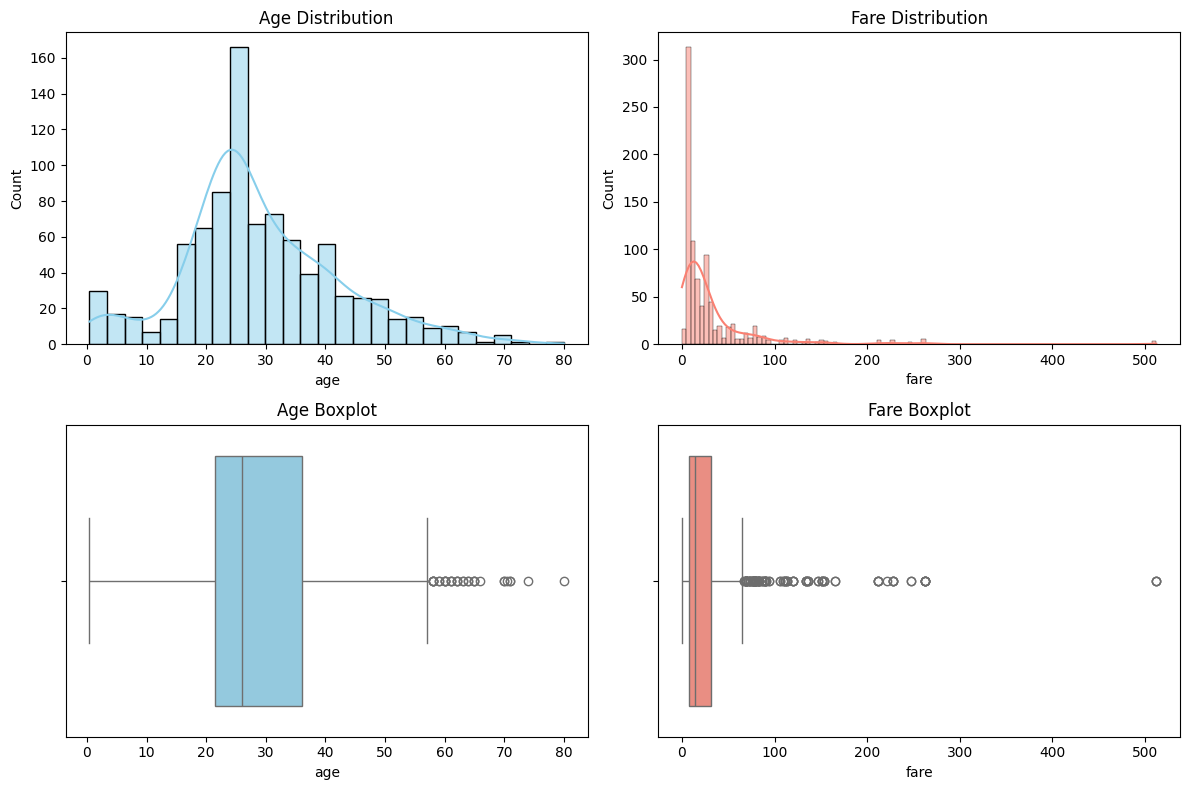


Age IQR Outliers: 32
Fare IQR Outliers: 114
Fare Central Tendency -> Mean: 32.10 | Median: 14.45 | Mode: 8.05

Survival Rates:
By Sex:
 sex
female    0.740385
male      0.188908
Name: survived, dtype: float64
By Pclass:
 pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64
By Sex & Pclass:
 sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


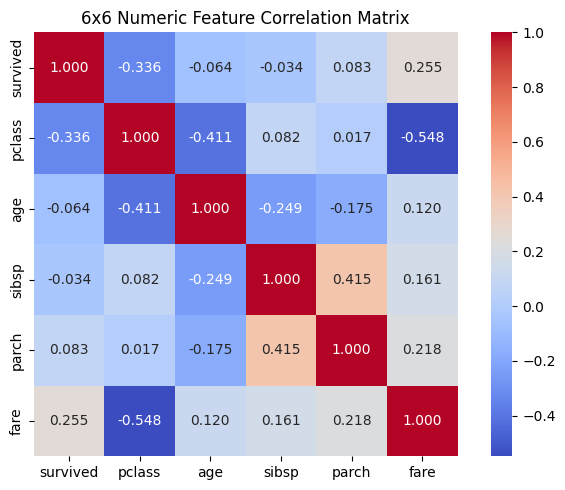

/tmp/ipykernel_476/165352803.py:82: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='pclass', y='survived', hue='sex', ci=None, ax=axes[0, 0], palette='Set2').set_title("1. Survival by Pclass & Sex")
/tmp/ipykernel_476/165352803.py:87: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='age_group', y='survived', hue='pclass', ci=None, ax=axes[1, 0], palette='Blues').set_title("3. Survival across Age Groups & Class")


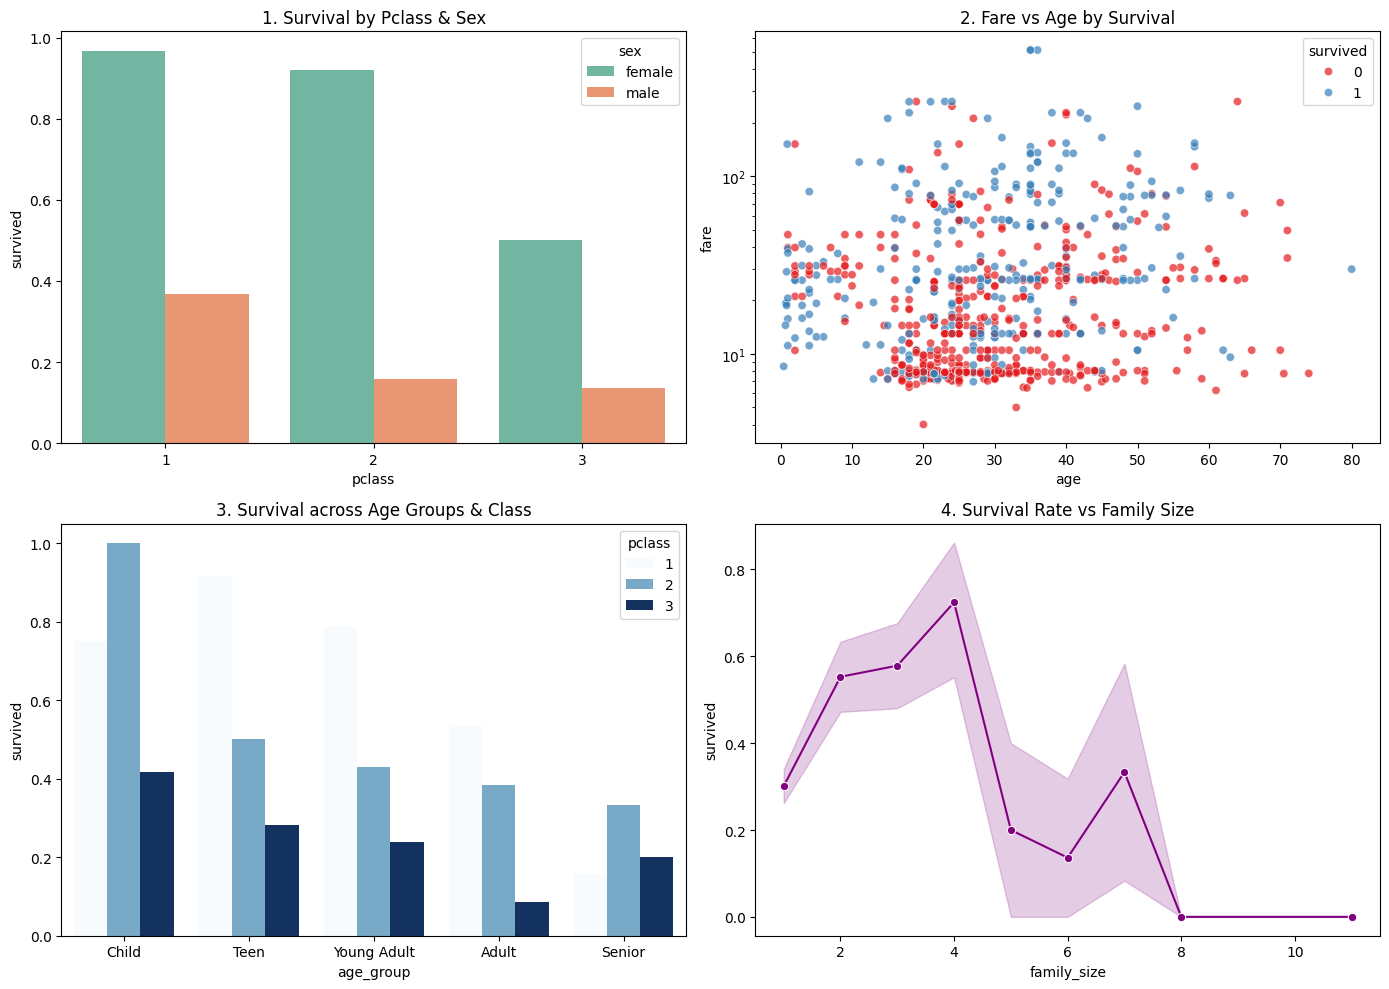


Standardized Age -> Mean: 2.7175e-16, Std: 1.0000
Standardized Fare -> Mean: 1.3188e-16, Std: 1.0000


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create folder for saving visual artifacts
os.makedirs("analytics/eda_charts", exist_ok=True)

print("="*60)
print("PART A: PROFILING, CLEANING & EDA")
print("="*60)

# 1. Dataset Load & Offline Fallback Creation
try:
    df_raw = sns.load_dataset('titanic')
    print("✅ Loaded dataset via Seaborn loader.")
except Exception as e:
    df_raw = pd.read_csv("titanic.csv")
    print("⚠️ Loaded from local fallback.")

print(f"\n[Shape]: {df_raw.shape}")
print("\n[DataFrame Info]:")
df_raw.info()

print("\n[Missing Values Summary]:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_Percent': missing_pct})
print(missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Percent', ascending=False))

# Primary committed offline fallback file
df_raw.to_csv("titanic.csv", index=False)
df_raw.to_csv("analytics/titanic.csv", index=False)
print("\n✅ Saved offline fallback 'titanic.csv'.")

# 2. Missing Value Handling
df = df_raw.copy()
df.drop(columns=['deck'], inplace=True) # >30% missing -> Drop
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median())) # 5-30% -> Impute median
df.dropna(subset=['embarked'], inplace=True) # <5% missing -> Drop rows

# 3. Univariate Analysis (Age & Fare)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['age'], kde=True, ax=axes[0, 0], color='skyblue').set_title("Age Distribution")
sns.histplot(df['fare'], kde=True, ax=axes[0, 1], color='salmon').set_title("Fare Distribution")
sns.boxplot(x=df['age'], ax=axes[1, 0], color='skyblue').set_title("Age Boxplot")
sns.boxplot(x=df['fare'], ax=axes[1, 1], color='salmon').set_title("Fare Boxplot")
plt.tight_layout()
plt.savefig("analytics/eda_charts/age_fare_univariate.png")
plt.show()

# Outliers via IQR Rule
def count_outliers(col):
    q1, q3 = col.quantile(0.25), col.quantile(0.75)
    iqr = q3 - q1
    return len(col[(col < (q1 - 1.5 * iqr)) | (col > (q3 + 1.5 * iqr))])

print(f"\nAge IQR Outliers: {count_outliers(df['age'])}")
print(f"Fare IQR Outliers: {count_outliers(df['fare'])}")
print(f"Fare Central Tendency -> Mean: {df['fare'].mean():.2f} | Median: {df['fare'].median():.2f} | Mode: {df['fare'].mode()[0]:.2f}")

# 4. Bivariate Survival Rates & Correlation Matrix
print("\nSurvival Rates:")
print("By Sex:\n", df.groupby('sex')['survived'].mean())
print("By Pclass:\n", df.groupby('pclass')['survived'].mean())
print("By Sex & Pclass:\n", df.groupby(['sex', 'pclass'])['survived'].mean())

# Restricted 6x6 Correlation Matrix
corr_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", square=True)
plt.title("6x6 Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("analytics/eda_charts/correlation_heatmap.png")
plt.show()

# 5. Multivariate Data Story (4 Charts)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=df, x='pclass', y='survived', hue='sex', ci=None, ax=axes[0, 0], palette='Set2').set_title("1. Survival by Pclass & Sex")
sns.scatterplot(data=df, x='age', y='fare', hue='survived', alpha=0.7, ax=axes[0, 1], palette='Set1').set_title("2. Fare vs Age by Survival")
axes[0, 1].set_yscale('log')

df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
sns.barplot(data=df, x='age_group', y='survived', hue='pclass', ci=None, ax=axes[1, 0], palette='Blues').set_title("3. Survival across Age Groups & Class")

df['family_size'] = df['sibsp'] + df['parch'] + 1
sns.lineplot(data=df, x='family_size', y='survived', marker='o', ax=axes[1, 1], color='purple').set_title("4. Survival Rate vs Family Size")
plt.tight_layout()
plt.savefig("analytics/eda_charts/multivariate_story.png")
plt.show()

# 6. Exploratory Z-Score Check
df_z = df.copy()
df_z['age_z'] = (df_z['age'] - df_z['age'].mean()) / df_z['age'].std()
df_z['fare_z'] = (df_z['fare'] - df_z['fare'].mean()) / df_z['fare'].std()
print(f"\nStandardized Age -> Mean: {df_z['age_z'].mean():.4e}, Std: {df_z['age_z'].std():.4f}")
print(f"Standardized Fare -> Mean: {df_z['fare_z'].mean():.4e}, Std: {df_z['fare_z'].std():.4f}")

PART B: PREDICTIVE MODELING PIPELINE


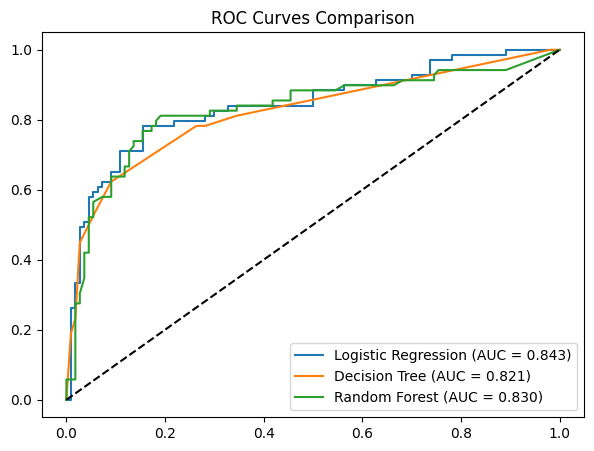

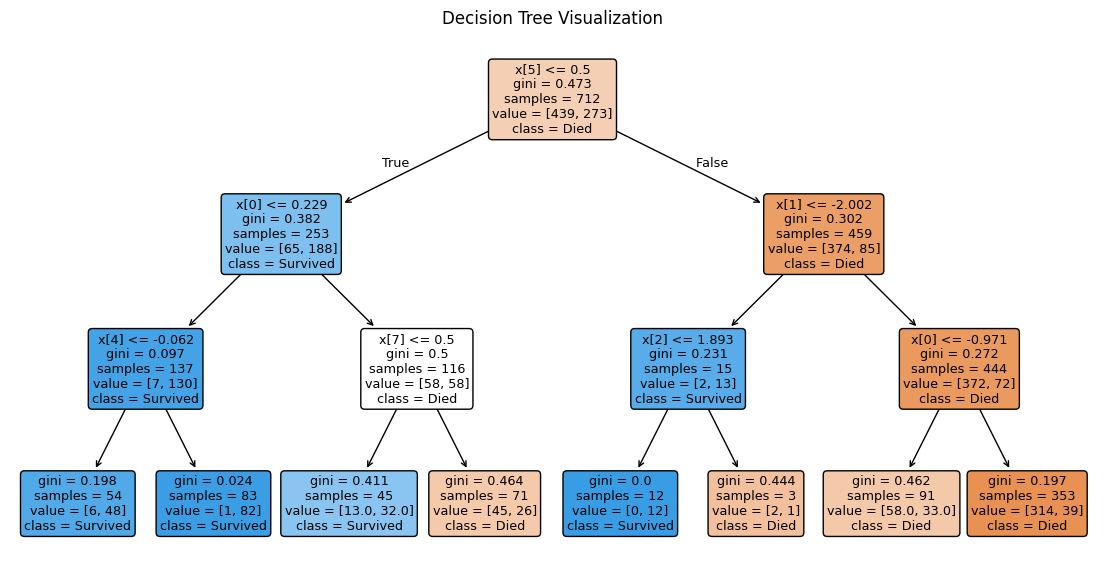


Classifier Metrics:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843478
1        Decision Tree  0.787709   0.844444  0.550725  0.666667  0.821014
2        Random Forest  0.810056   0.769231  0.724638  0.746269  0.830171

Train-only SMOTE -> Precision: 0.7286, Recall: 0.7391, F1: 0.7338

Best Parameters: {'classifier__max_depth': 8, 'classifier__max_features': 'log2', 'classifier__n_estimators': 50}
Calculated OOB Score: 0.8188

Regression Metrics -> MAE: 20.90 | RMSE: 30.53 | R2: 0.3975 | Adj R2: 0.3729


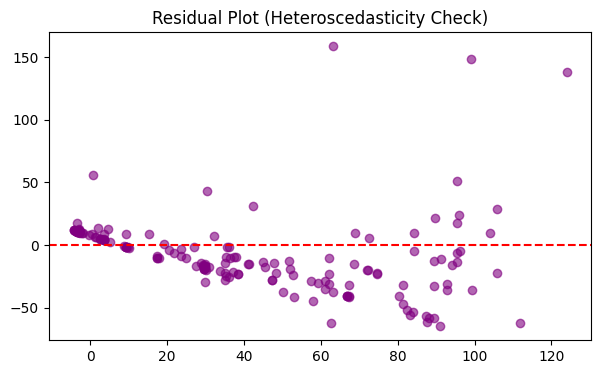


✅ Pipeline Test Prediction for Mock Input: Survived


In [ ]:
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
from imblearn.over_sampling import SMOTE

print("="*60)
print("PART B: PREDICTIVE MODELING PIPELINE")
print("="*60)

# Load clean data
df = pd.read_csv("titanic.csv")

# 7. Stratified Train/Test Split
feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[feature_cols]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 8. Preprocessing Pipelines
num_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
cat_features = ['sex', 'embarked']

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', num_pipe, num_features), ('cat', cat_pipe, cat_features)])

# 9 & 10. Model Training & Metric Evaluation
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
plt.figure(figsize=(7, 5))

for name, clf in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train) # Fit ONLY on train data

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc})

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves Comparison')
plt.legend()
plt.savefig("analytics/eda_charts/roc_curves.png")
plt.show()

# Visualize Decision Tree
dt_pipe = Pipeline([('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier(max_depth=3, random_state=42))])
dt_pipe.fit(X_train, y_train)

plt.figure(figsize=(14, 7))
plot_tree(dt_pipe.named_steps['classifier'], filled=True, rounded=True, class_names=['Died', 'Survived'])
plt.title("Decision Tree Visualization")
plt.savefig("analytics/eda_charts/decision_tree.png")
plt.show()

print("\nClassifier Metrics:")
print(pd.DataFrame(results))

# 11. Imbalance Handling Comparison (Train fold only)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# SMOTE on train fold
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_prep, y_train)

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test_prep)

print(f"\nTrain-only SMOTE -> Precision: {precision_score(y_test, y_pred_smote):.4f}, Recall: {recall_score(y_test, y_pred_smote):.4f}, F1: {f1_score(y_test, y_pred_smote):.4f}")

# 12. Hyperparameter Tuning (RandomForest with oob_score=True)
rf_tuning = RandomForestClassifier(oob_score=True, random_state=42)
pipe_grid = Pipeline([('preprocessor', preprocessor), ('classifier', rf_tuning)])

param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5, 8],
    'classifier__max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(pipe_grid, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

best_pipeline = grid.best_estimator_
print("\nBest Parameters:", grid.best_params_)
print(f"Calculated OOB Score: {best_pipeline.named_steps['classifier'].oob_score_:.4f}")

# 13. Regression Side-Task (Predicting Fare)
X_reg, y_reg = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked', 'survived']], df['fare']
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.20, random_state=42)

reg_num = ['pclass', 'age', 'sibsp', 'parch', 'survived']
reg_cat = ['sex', 'embarked']

reg_prep = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler())]), reg_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('enc', OneHotEncoder(drop='first'))]), reg_cat)
])

reg_pipe = Pipeline([('prep', reg_prep), ('reg', LinearRegression())])
reg_pipe.fit(X_tr_r, y_tr_r)
y_reg_pred = reg_pipe.predict(X_te_r)

mae = mean_absolute_error(y_te_r, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_te_r, y_reg_pred))
r2 = r2_score(y_te_r, y_reg_pred)
adj_r2 = 1 - ((1 - r2) * (len(y_te_r) - 1) / (len(y_te_r) - X_tr_r.shape[1] - 1))

print(f"\nRegression Metrics -> MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f} | Adj R2: {adj_r2:.4f}")

# Residuals Plot
plt.figure(figsize=(7, 4))
plt.scatter(y_reg_pred, y_te_r - y_reg_pred, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (Heteroscedasticity Check)')
plt.savefig("analytics/eda_charts/regression_residuals.png")
plt.show()

# 14 & 15. Export & Verification
joblib.dump(best_pipeline, "analytics/best_titanic_pipeline.joblib")
joblib.dump(best_pipeline, "best_titanic_pipeline.joblib")

# Reload test
reloaded = joblib.load("analytics/best_titanic_pipeline.joblib")
mock = pd.DataFrame([{'pclass': 1, 'sex': 'female', 'age': 25.0, 'sibsp': 0, 'parch': 0, 'fare': 100.0, 'embarked': 'C'}])
print(f"\n✅ Pipeline Test Prediction for Mock Input: {'Survived' if reloaded.predict(mock)[0] == 1 else 'Died'}")